# Ejercicio 4: Comparación Experimental
## Merge Sort vs Insertion Sort

### 1. Importación de librerías

Se importan las librerías necesarias para la generación de datos aleatorios, la medición del tiempo de ejecución y la visualización de los resultados.

In [1]:
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Implementación de Merge Sort

Se definen dos funciones:
- `merge(left, right)`: fusiona dos subarreglos ordenados en uno solo.
- `merge_sort(arr)`: divide recursivamente el arreglo hasta el caso base (1 elemento) y combina los resultados.

Complejidad temporal: **O(n log n)**.

In [2]:
def merge(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    return result


def merge_sort(arr):
    # Caso base: un solo elemento ya está ordenado
    if len(arr) <= 1:
        return arr

    # Dividir
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    # Combinar
    return merge(left, right)

### 3. Implementación de Insertion Sort

La función `insertion_sort(arr)` construye el arreglo ordenado un elemento a la vez, insertando cada nuevo elemento en su posición correcta dentro de la parte ya ordenada.

Complejidad temporal: **O(n²)** en el peor caso.

In [3]:
def insertion_sort(arr):
    for j in range(1, len(arr)):
        key = arr[j]
        i = j - 1
        while i >= 0 and arr[i] > key:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key
    return arr

### 4. Función para medir tiempos

Genera un arreglo aleatorio de exactamente `n` elementos (valores entre -10000 y 10000). Mide el tiempo de cada algoritmo **por separado**, con los prints de verificación fuera del bloque de medición para no contaminar los resultados.

In [4]:
def medir_tiempo(n):
    # Arreglo de exactamente n elementos con valores aleatorios
    arr = [random.randint(-10000, 10000) for _ in range(n)]
    arr1 = arr.copy()

    # --- Merge Sort ---
    inicio_t1 = time.time()
    resultado_ms = merge_sort(arr)
    fin_t1 = time.time()

    # --- Insertion Sort ---
    inicio_t2 = time.time()
    resultado_is = insertion_sort(arr1)
    fin_t2 = time.time()

    # Verificación de resultados (fuera del bloque de medición)
    print(f'n={n}')
    print(f'  Merge Sort    -> primeros 10 elementos: {resultado_ms[:10]}')
    print(f'  Insertion Sort-> primeros 10 elementos: {resultado_is[:10]}')
    print(f'  Tiempo Merge Sort:     {fin_t1 - inicio_t1:.6f} s')
    print(f'  Tiempo Insertion Sort: {fin_t2 - inicio_t2:.6f} s\n')

    return fin_t1 - inicio_t1, fin_t2 - inicio_t2

### 5. Medición para n = 10, 50, 100, 500, 1000, 5000

In [5]:
random.seed(42)  # Reproducibilidad

tiempos_merge_sort = []
tiempos_insertion_sort = []
datos = [10, 50, 100, 500, 1000, 5000]

for n in datos:
    t_ms, t_is = medir_tiempo(n)
    tiempos_merge_sort.append(t_ms)
    tiempos_insertion_sort.append(t_is)

n=10
  Merge Sort    -> primeros 10 elementos: [-9181, -7152, -6642, -6352, -5428, -2686, -1976, -988, 7870, 9349]
  Insertion Sort-> primeros 10 elementos: [-9181, -7152, -6642, -6352, -5428, -2686, -1976, -988, 7870, 9349]
  Tiempo Merge Sort:     0.000081 s
  Tiempo Insertion Sort: 0.000009 s

n=50
  Merge Sort    -> primeros 10 elementos: [-9788, -9131, -9024, -8959, -8577, -8499, -7721, -7418, -7386, -6961]
  Insertion Sort-> primeros 10 elementos: [-9788, -9131, -9024, -8959, -8577, -8499, -7721, -7418, -7386, -6961]
  Tiempo Merge Sort:     0.000169 s
  Tiempo Insertion Sort: 0.000097 s

n=100
  Merge Sort    -> primeros 10 elementos: [-9982, -9894, -9624, -9362, -8949, -8457, -8168, -7919, -7832, -7661]
  Insertion Sort-> primeros 10 elementos: [-9982, -9894, -9624, -9362, -8949, -8457, -8168, -7919, -7832, -7661]
  Tiempo Merge Sort:     0.000325 s
  Tiempo Insertion Sort: 0.000344 s

n=500
  Merge Sort    -> primeros 10 elementos: [-9987, -9945, -9930, -9884, -9819, -9807, -9

### 6. Gráfica comparativa (matplotlib + seaborn)

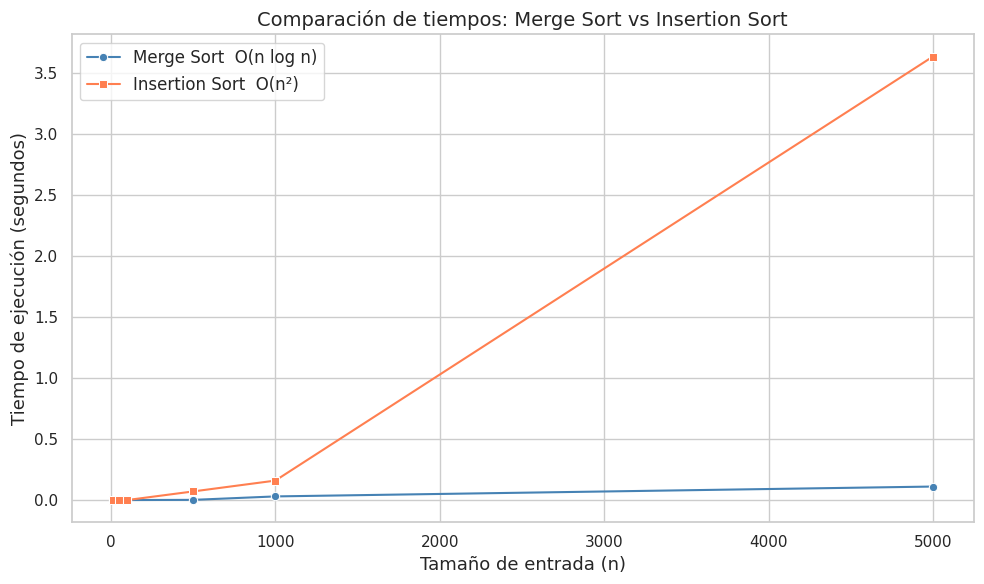

In [6]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.lineplot(x=datos, y=tiempos_merge_sort,    label='Merge Sort  O(n log n)', marker='o', color='steelblue')
sns.lineplot(x=datos, y=tiempos_insertion_sort, label='Insertion Sort  O(n²)',  marker='s', color='coral')

plt.xlabel('Tamaño de entrada (n)', fontsize=13)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=13)
plt.title('Comparación de tiempos: Merge Sort vs Insertion Sort', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('../resultados/grafica_merge_vs_insertion.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Conclusiones

**1. Crecimiento del tiempo de ejecución:**  
La gráfica muestra claramente que **Insertion Sort** presenta un crecimiento cuadrático (O(n²)): su tiempo de ejecución aumenta de forma muy pronunciada a medida que n crece, siendo especialmente notorio a partir de n=1000 y crítico en n=5000.  
**Merge Sort**, por su parte, crece de forma mucho más lenta (O(n log n)), manteniéndose cerca del eje horizontal incluso para n=5000.

**2. Punto de cruce:**  
Para entradas muy pequeñas (n ≤ 50), Insertion Sort puede ser comparable o incluso ligeramente más rápido que Merge Sort, debido a que tiene menor overhead de memoria y llamadas recursivas. A partir de n=100 la ventaja de Merge Sort comienza a ser visible, y para n=5000 la diferencia es drástica.

**3. Uso de memoria:**  
Insertion Sort ordena **in-place** (no necesita memoria adicional), mientras que Merge Sort requiere arreglos auxiliares en cada nivel de recursión (O(n) de espacio adicional). Esto representa un trade-off: Merge Sort es más rápido en tiempo pero más costoso en memoria.

**4. Estabilidad:**  
Ambos algoritmos son **estables** (mantienen el orden relativo de elementos iguales), lo cual es una propiedad deseable en ciertos contextos de ordenamiento.

**5. Conclusión general:**  
Para arreglos grandes, Merge Sort es claramente superior en rendimiento temporal. Insertion Sort es preferible solo cuando el arreglo es pequeño, está casi ordenado, o cuando las restricciones de memoria son críticas. En la práctica, algoritmos como Python's Timsort combinan ambos enfoques: usan Insertion Sort para subarreglos pequeños y Merge Sort para combinarlos.